In [3]:
import sqlite3

# Connect to database (creates it if it doesn't exist)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create table using triple quotes for the SQL query
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sales_data = [
    ('Apples', 10, 2.5),
    ('Oranges', 5, 3.0),
    ('Bananas', 8, 1.8),
    ('Apples', 7, 2.5),
    ('Oranges', 10, 3.0),
    ('Bananas', 12, 1.8),
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)

# Commit and close
conn.commit()
conn.close()

print("Database created and data inserted.")


Database created and data inserted.


Sales Summary:
   product  total_qty  revenue
0   Apples         34     85.0
1  Bananas         40     72.0
2  Oranges         30     90.0


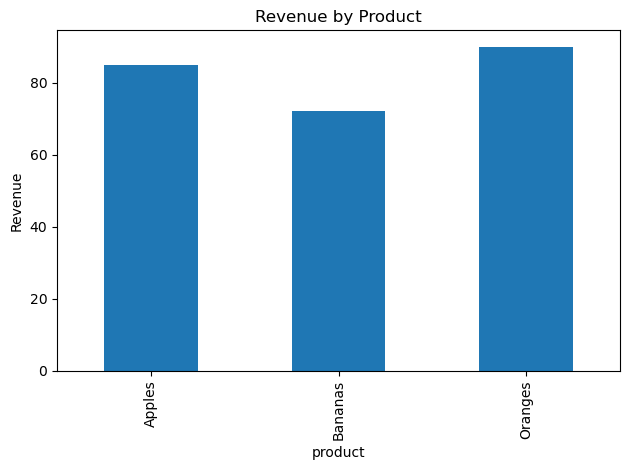

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to SQLite DB
conn = sqlite3.connect("sales_data.db")

# SQL Query: Group by product
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

# Load result into DataFrame
df = pd.read_sql_query(query, conn)
conn.close()

# Print result
print("Sales Summary:")
print(df)

# Plot bar chart of revenue
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', legend=False)
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()
